In [1]:
# Import important libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import chardet
import re

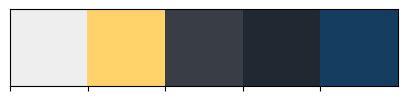

In [2]:
# Determine the colors which we will use in the whole project
colors = ['#EEEEEE','#FFD369','#393E46','#222831',"#143D60"]
sns.palplot(colors)

In [3]:
# Predict the possible encoding
with open('netflix.csv','rb') as f:
    result = chardet.detect(f.read(100000))
    print(result)

{'encoding': 'Windows-1254', 'confidence': 0.5203533026128195, 'language': 'Turkish'}


## Load Data

In [4]:
# The confidence of the encoding is very low (52%) so that i use "ISO-8859-1"
df = pd.read_csv('netflix.csv',sep=None, engine='python',encoding='ISO-8859-1')
df.head(5)

,Title,Available Globally?,Release Date,Hours Viewed,Language Indicator,Content Type
0,The Night Agent: Season 1,Yes,23/03/23,"81,21,00,000",English,Show
1,Ginny & Georgia: Season 2,Yes,05/01/23,"66,51,00,000",English,Show
2,The Glory: Season 1 // Ó üÛÁÏ_Â: ÜÏ_Î 1,Yes,30/12/22,"62,28,00,000",Korean,Show
3,Wednesday: Season 1,Yes,23/11/22,"50,77,00,000",English,Show
4,Queen Charlotte: A Bridgerton Story,Yes,04/05/23,"50,30,00,000",English,Movie


## Preprocessing Data

In [5]:
# Make underline on each column, convert release date into datetime format, and convert hours_viewed into float format
df.columns = df.columns.str.replace(' ','_').str.lower()
df['release_date'] = pd.to_datetime(df['release_date'])
df['hours_viewed'] = df['hours_viewed'].str.replace(",",'',regex=True).astype(dtype=float)

/var/folders/w3/_6s2j6wx66l5nq6xj6cbw_b00000gn/T/ipykernel_1250/2486882162.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['release_date'] = pd.to_datetime(df['release_date'])


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24812 entries, 0 to 24811
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   title                24812 non-null  object        
 1   available_globally?  24812 non-null  object        
 2   release_date         8166 non-null   datetime64[ns]
 3   hours_viewed         24812 non-null  float64       
 4   language_indicator   24812 non-null  object        
 5   content_type         24812 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 1.1+ MB


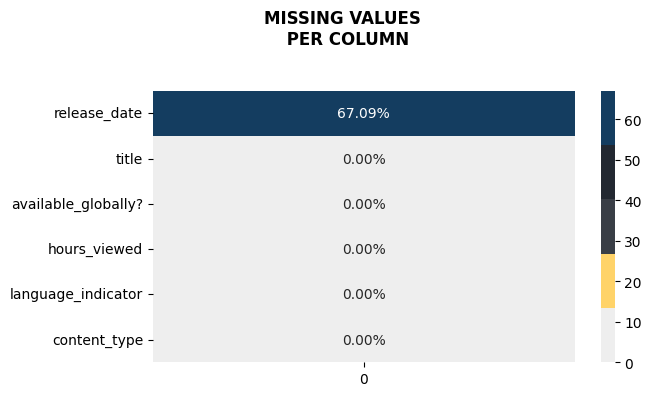

In [7]:
# Show the percentage of missing values
fig, axs = plt.subplots(figsize=(7,4))

nan_data_numerical = round(100*(df.isna().sum())/(len(df.index)), 2).sort_values(ascending = False).to_frame()
annot_labels = nan_data_numerical.map(lambda x: f"{x:.2f}%" if x>0 or x<0 else "0.00%" )
plt1 = sns.heatmap(nan_data_numerical, cmap = colors, annot=annot_labels,ax = axs, fmt='', cbar_kws={'orientation':'vertical'})
plt.suptitle('MISSING VALUES \n PER COLUMN\n', fontsize=12, fontweight = 'bold')
plt.tight_layout()

In [8]:
# Make a copy the dataframe
netflix = df.copy()

## FINDINGS

### Distribution of Content Type and Language Indicator

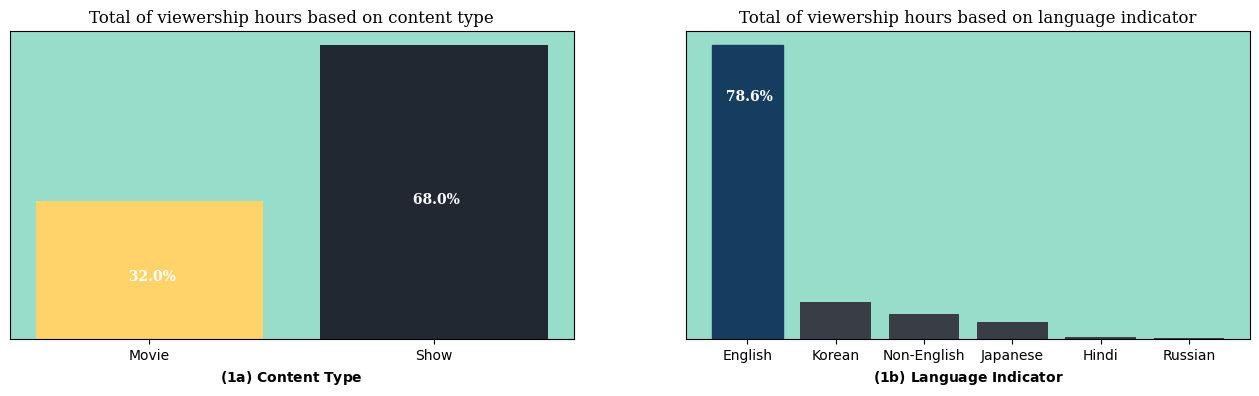

In [9]:
fig,ax = plt.subplots(1,2,figsize=(16,4), subplot_kw={'facecolor':'#98DDCA'})
content_type = netflix.groupby('content_type')['hours_viewed'].sum()
hours_view = netflix.groupby('language_indicator')['hours_viewed'].sum().sort_values(ascending=False)

bars1 = ax[0].bar(content_type.index,content_type.values, color=[colors[1],colors[3]])
ax[0].set_title('Total of viewership hours based on content type',fontsize='12',family='serif',loc='center')
ax[0].yaxis.set_visible(False)
ax[0].set_xlabel(r'$\mathbf{(1a)}$ Content Type',fontweight='bold')
for bar,val in zip(bars1, content_type.values):
    perc_cont_type = (val/content_type.values.sum())*100
    ax[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*0.5, f'{perc_cont_type: .1f}%', 
               ha='center', va='top', family='serif',fontsize=10, color='white', fontweight='bold')

bars2 = ax[1].bar(hours_view.index, hours_view.values, color=colors[2])
ax[1].set_title('Total of viewership hours based on language indicator', fontsize='12', family='serif', loc='center')
ax[1].yaxis.set_visible(False)
ax[1].set_xlabel(r'$\mathbf{(1b)}$ Language Indicator', fontweight='bold')
bar_to_label = bars2[0]
bar_to_label.set_color(colors[4])
perc_view_hours = (bar_to_label.get_height()/hours_view.values.sum())*100
ax[1].text(bar_to_label.get_x() + bar_to_label.get_width()/2, bar_to_label.get_height()*0.85, f'{perc_view_hours: .1f}%', 
            ha='center', va='top', family='serif',fontsize=10, color='white', fontweight='bold')

plt.show()

### Distribution Analysis on Yearly, Monthly and Daily

In [10]:
# Parse date release into its year, month and day of week
netflix['year'] = netflix['release_date'].dt.year
netflix['month'] = netflix['release_date'].dt.month
netflix['day_of_week']= netflix['release_date'].dt.day_of_week

# Group year,month,and day of week based on sum of the hours viewed
year_trend = netflix.groupby('year')['hours_viewed'].sum()
month_trend = netflix.groupby('month')['hours_viewed'].sum()
daily_trend = netflix.groupby('day_of_week')['hours_viewed'].sum()

In [11]:
# Manual mapping for months and days
month_mapping = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
    7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

day_mapping = {
    0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu",
    4: "Fri", 5: "Sat", 6: "Sun"
}

# Convert numerical indices to mapped labels
month_labels = [month_mapping[m] for m in month_trend.index]
day_labels = [day_mapping[d] for d in daily_trend.index]

In [12]:
# Yearly trend
year_dist_title = netflix.groupby('year')['title'].count()
year_conc = pd.DataFrame({'year':year_dist_title.index,'dist':year_dist_title.values,'total_hours':year_trend.values})
year_conc = year_conc.set_index('year')

# Monthly trend
month_dist_title = netflix.groupby('month')['title'].count()
month_conc = pd.DataFrame({'month':month_dist_title.index,'dist':month_dist_title.values,'total_hours':month_trend.values})
month_conc = month_conc.set_index('month')

# Daily trend
daily_dist_title = netflix.groupby('day_of_week')['title'].count()
day_conc = pd.DataFrame({'day_of_week':daily_dist_title.index,'dist':daily_dist_title.values,'total_hours':daily_trend.values})
day_conc = day_conc.set_index('day_of_week')

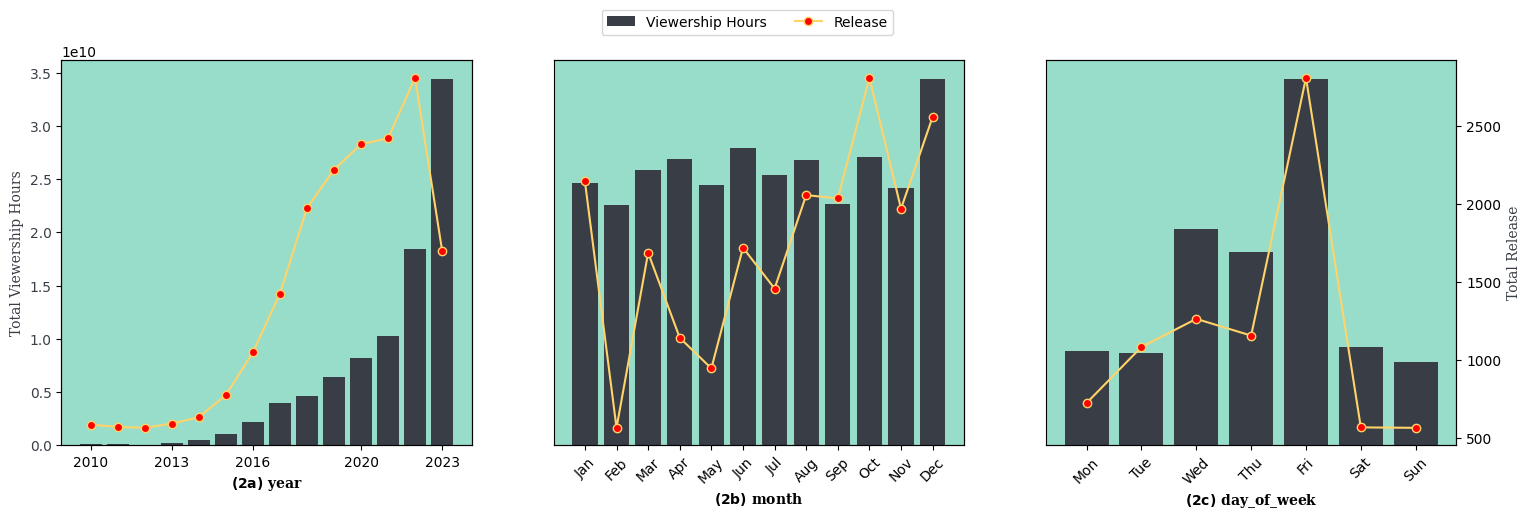

In [13]:
# Plot trend
fig,ax = plt.subplots(1,3,figsize=(18,5), subplot_kw={'facecolor':'#98DDCA'})

# yearly trend part
ax[0].bar(year_conc.index, year_conc.total_hours, color=colors[2])
ax[0].set_ylabel('Total Viewership Hours', family='serif', color=colors[2])
ax[0].set_xlabel(r'$\mathbf{(2a)}$ year', family='serif',fontweight='bold')
ax[0].set_xticks([2010,2013,2016,2020,2023])
for label in ax[0].get_yticklabels():
    label.set_color(color=colors[2])

ax0 = ax[0].twinx()
ax0.plot(year_conc.index, year_conc.dist, color=colors[1], marker='o', markerfacecolor='red')
ax0.yaxis.set_visible(False)

#monthly trend part
bar_plot = ax[1].bar(month_conc.index, month_conc.total_hours, color=colors[2])
ax[1].set_xlabel(r'$\mathbf{(2b)}$ month', family='serif',fontweight='bold')
ax[1].set_xticks(month_trend.index)
ax[1].set_xticklabels(month_labels, rotation=45)

ax1 = ax[1].twinx()
line_plot, = ax1.plot(month_conc.index, month_conc.dist, color=colors[1], marker='o', markerfacecolor='red')
ax1.yaxis.set_visible(False)
ax[1].spines['left'].set_visible(False)
ax[1].yaxis.set_ticks([])
ax[1].set_ylabel('')

handles = [bar_plot, line_plot]
labels = ['Viewership Hours', 'Release']
ax[1].legend(handles, labels, loc='upper left', bbox_to_anchor=(0.1, 1.15), ncol=2)

#daily trend part
ax[2].bar(day_conc.index, day_conc.total_hours, color=colors[2])
ax[2].set_xlabel(r'$\mathbf{(2c)}$ day_of_week', family='serif',fontweight='bold')
ax[2].set_xticks(daily_trend.index)
ax[2].set_xticklabels(day_labels, rotation=45)

ax2 = ax[2].twinx()
ax2.plot(day_conc.index, day_conc.dist, color=colors[1], marker='o', markerfacecolor='red')
ax2.set_ylabel('Total Release', color=colors[2], family='serif')
ax[2].spines['left'].set_visible(False)
ax[2].yaxis.set_ticks([])
ax[2].set_ylabel('')

plt.show()


In [14]:
list_feb = ['Outer Banks: Season 3', 'Ginny & Georgia: Season 1',
       'Firefly Lane: Season 2'] # 3 release which above 250 millions viewership hours.

# Season and Event

In [15]:
# define significant holidays and events in 2022-2023
important_dates = pd.to_datetime([
    '2022-01-01',  # new year's day
    '2022-02-14',  # valentine's day
    '2022-10-31',  # halloween
    '2022-12-25',  # christmas day
    '2023-01-01',  # new year's day
    '2023-02-14',  # valentine's day
    '2023-10-31',  # halloween
    '2023-12-25',  # christmas day
    '2024-01-01',  # new year's day
])

# Apply to dataframe
def classify_holiday(df):
    if pd.isna(df['release_date']): 
        return np.nan
    if df['year'] in [2022,2023]:
        if any((df['release_date'] - date).days in range(-14,15) for date in important_dates):
            return 'event'
        else:
            return 'not_event'
    else:
        return 'not_included'

netflix['holiday'] = netflix.apply(classify_holiday, axis=1)

In [16]:
# 1. Buat distribusi antara persentase total viewership antara yg holiday dan non-holiday
filtered_netflix = netflix[netflix['holiday'].isin(['event','not_event'])]
holiday_dist = (
    filtered_netflix.groupby('holiday')['hours_viewed'].sum()/
    filtered_netflix['hours_viewed'].sum()
    )
holiday_dist

holiday
event        0.251019
not_event    0.748981
Name: hours_viewed, dtype: float64

In [17]:
def get_season(month):
    return ('winter' if month in [12,1,2] else
            'spring' if month in [3,4,5] else
            'summer' if month in [6,7,8] else
            'fall' if month in [9,10,11] else
            np.nan)
netflix['release_season'] = netflix['month'].apply(get_season)

In [18]:
# aggregate viewership hours by release season
seasonal_viewership = netflix.groupby('release_season')['hours_viewed'].sum()
seasonal_release = netflix.groupby('release_season')['title'].count()
season_conc = pd.DataFrame({'season':seasonal_release.index,'dist':seasonal_release.values,'total_hours':seasonal_viewership.values})
season_conc = season_conc.set_index('season')
# Define the desired order
season_order = ['fall','winter', 'spring','summer']
# Reorder the DataFrame index
season_conc = season_conc.reindex(season_order)

In [19]:
fall = netflix[netflix['release_season'] == 'fall']
winter = netflix[netflix['release_season'] == 'winter']
summer = netflix[netflix['release_season'] == 'summer']
spring = netflix[netflix['release_season'] == 'spring']

In [20]:
winter.sort_values(by=['hours_viewed'], ascending=False)[winter['month'] == 2].head(10)

/var/folders/w3/_6s2j6wx66l5nq6xj6cbw_b00000gn/T/ipykernel_1250/2666197384.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  winter.sort_values(by=['hours_viewed'], ascending=False)[winter['month'] == 2].head(10)


,title,available_globally?,release_date,hours_viewed,language_indicator,content_type,year,month,day_of_week,holiday,release_season
7,Outer Banks: Season 3,Yes,2023-02-23,402500000.0,English,Show,2023.0,2.0,3.0,event,winter
8,Ginny & Georgia: Season 1,Yes,2021-02-24,302100000.0,English,Show,2021.0,2.0,2.0,not_included,winter
12,Firefly Lane: Season 2,Yes,2022-02-12,251500000.0,English,Show,2022.0,2.0,5.0,event,winter
29,Perfect Match: Season 1,Yes,2023-02-14,176800000.0,English,Show,2023.0,2.0,1.0,event,winter
30,Sex/Life: Season 2,Yes,2023-02-03,175500000.0,English,Show,2023.0,2.0,4.0,event,winter
54,Triptych: Season 1 // TrÌ_ada: Temporada 1,Yes,2023-02-22,139300000.0,Non-English,Show,2023.0,2.0,2.0,event,winter
18225,All the Light We Cannot See: Limited Series,Yes,2023-02-11,129900000.0,English,Movie,2023.0,2.0,5.0,event,winter
68,We Have a Ghost,Yes,2023-02-24,124400000.0,English,Movie,2023.0,2.0,4.0,event,winter
70,Business Proposal: Season 1 // âÂâ«¤_ãÊ: ...,Yes,2022-02-28,120700000.0,Korean,Show,2022.0,2.0,0.0,event,winter
76,Vikings: Valhalla: Season 1,Yes,2022-02-25,116500000.0,English,Show,2022.0,2.0,4.0,event,winter


In [21]:
title,content_type,language,holiday = [],[],[],[]

season_list = [fall,winter,spring,summer]
for season in season_list:
    title.append(season.sort_values(by=['hours_viewed'], ascending=False)['title'].iloc[0])
    content_type.append(season.sort_values(by=['hours_viewed'], ascending=False)['content_type'].iloc[0])
    language.append(season.sort_values(by=['hours_viewed'], ascending=False)['language_indicator'].iloc[0])
    holiday.append(season.sort_values(by=['hours_viewed'], ascending=False)['holiday'].iloc[0])

dict_season = {'title':title, 'content_type':content_type,'language':language,'holiday':holiday}

In [22]:
# Genre of each top contributor
genre_list = ['comedy-horror','thriller-melodrama','action-adventure-thriller','romantic-comedy']
dict_season['genre'] = genre_list

#Percentage value of each top contributor
winter_filter = winter.sort_values(by='hours_viewed', ascending=False)
summer_filter = summer.sort_values(by='hours_viewed', ascending=False)
fall_filter = fall.sort_values('hours_viewed', ascending=False)
spring_filter = spring.sort_values(by='hours_viewed', ascending=False)
summ = summer[summer['hours_viewed'] != summer_filter['hours_viewed'].iloc[0]]
win = winter[winter['hours_viewed'] != winter_filter['hours_viewed'].iloc[0]]
fal = fall[fall['hours_viewed'] != fall_filter['hours_viewed'].iloc[0]]
spr = spring[spring['hours_viewed'] != spring_filter['hours_viewed'].iloc[0]]

perc_fall = (1-(fal['hours_viewed'].sum()/fall['hours_viewed'].sum()))*100
perc_winter = (1-(win['hours_viewed'].sum()/winter['hours_viewed'].sum()))*100
perc_spring = (1-(spr['hours_viewed'].sum()/spring['hours_viewed'].sum()))*100
perc_summer = (1-(summ['hours_viewed'].sum()/summer['hours_viewed'].sum()))*100

list_contr = [perc_fall,perc_winter,perc_spring,perc_summer]
dict_season['contributor'] = list_contr

In [23]:
def clean_title(title):
    title = re.sub(r'[^\x00-\x7F]+','', title) # remove non ascii characters
    title = re.sub(r'[_//:]+','',title) # remove _//: characters
    title = title.strip() # remove space
    return title
dict_season['title'] = [clean_title(title) for title in dict_season['title']]

In [24]:
# Convert top title data to DataFrame
top_titles_df = pd.DataFrame(dict_season)

# Combine seasonal data
top_titles_df['season'] = season_order
top_titles_df = top_titles_df.set_index('season')

season_concate = season_conc.merge(top_titles_df, how='left',on='season')

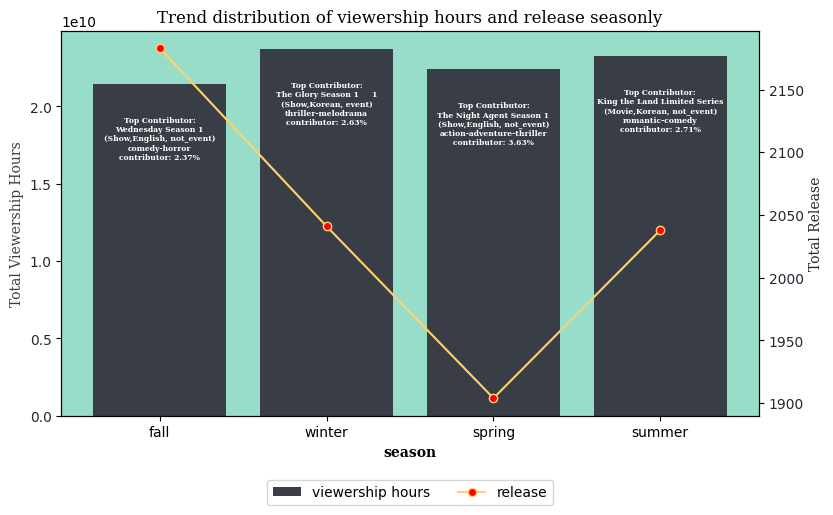

In [25]:
fig,ax1 = plt.subplots(figsize=(9,5), subplot_kw={'facecolor':'#98DDCA'})
bar_plot = ax1.bar(season_concate.index, season_concate.total_hours, color=colors[2])
ax1.set_ylabel('Total Viewership Hours', family='serif', color=colors[2])
ax1.set_title('Trend distribution of viewership hours and release seasonly', loc='center', family='serif', fontsize=12)
ax1.set_xlabel('season', family='serif',fontweight='bold')
for label in ax1.get_yticklabels():
    label.set_color(color=colors[3])

ax2 = ax1.twinx()
line_plot, = ax2.plot(season_concate.index, season_concate.dist, marker='o', markerfacecolor='red', color=colors[1])
ax2.set_ylabel('Total Release', family='serif', color=colors[3])
for label in ax2.get_yticklabels():
    label.set_color(color=colors[3])

for i,season in enumerate(season_order):
    top_contributor = season_concate.loc[season]
    # Construct annotation text with the top title details
    annotation_text = f"Top Contributor:\n{top_contributor.title}\n({top_contributor.content_type},{top_contributor.language}, {top_contributor.holiday})\n{top_contributor.genre}\ncontributor:{top_contributor.contributor: .2f}%"
    
    # Add annotation above the bar
    ax1.text(i, top_contributor.total_hours - 0.5e10, annotation_text, 
                ha='center', va='bottom', fontsize=5.5, family='serif', color='white', fontweight='bold')

handles = [bar_plot,line_plot]
labels = ['viewership hours','release']
ax2.legend(handles,labels, bbox_to_anchor=(0.5,-0.25), loc='lower center', ncol=2)

plt.show()